# Class 3: Word Embeddings & Sentiment Analysis
## Learning Notebook Part 1 - Introducing Word Embeddings

**Welcome!** This notebook introduces **word embeddings** - dense vectors that capture semantic meaning.

**What you've learned so far:**
- ✅ Class 1 & 2: Text preprocessing, TF-IDF, similarity search
- ✅ You know TF-IDF is **syntactic** (word-based, no meaning)
- ✅ You understand the limitation: TF-IDF treats synonyms as different ("great" ≠ "excellent")
- ✅ You know words as points in space (geometric intuition from Class 1 & 2)

**Today you'll learn:**
- 🎯 **Word embeddings** - dense vectors that capture semantic meaning
- 🎯 **Word2Vec, GloVe, and FastText** - three popular embedding methods
- 🎯 **Visualize embeddings** - see how similar words cluster together in space
- 🎯 **Vector arithmetic** - the famous "king - man + woman ≈ queen" example
- 🎯 **OOV handling** - how FastText handles unknown words

**Main Purpose**: 
- **Introduce word embeddings** (dense vectors vs sparse TF-IDF)
- **Explore and visualize** Word2Vec, GloVe, and FastText
- **See** how embeddings capture semantic relationships (similarities, vector arithmetic)
- **Compare** different embedding methods

**Next**: In Part 2, we'll use these embeddings for sentiment analysis (supervised learning)!

**By the end**: You'll EXPERIENCE how embeddings understand meaning! You'll see "great" and "excellent" are close in embedding space - this solves the limitation from Class 2!

**Key Insight**: **Semantic = meaning**. Embeddings are semantic - they understand meaning and synonyms!


---

## Setup


In [22]:
# Install required packages if not already installed
# Install required packages if not already installed
# Uncomment the line below if gensim is not installed
# !pip install gensim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")
print("📊 Ready to visualize embeddings!")


✓ Libraries imported successfully!
📊 Ready to visualize embeddings!


---

## Section 1: Understanding the Problem - Sparse vs Dense

**Remember from Class 2:**
- TF-IDF is **syntactic** (word-based, no meaning)
- TF-IDF treats synonyms as completely different words
- "great" and "excellent" have similarity ≈ 0 (no shared words!)

**The Solution: Word Embeddings**
- **Dense vectors** that capture semantic meaning
- Similar words are close in embedding space
- "great" and "excellent" are close together!

**Visual Comparison:**
```
TF-IDF (Sparse):
"great"    [0, 0, 1, 0, 0, 0, ...]  ← Dimension 3
"excellent" [0, 0, 0, 0, 1, 0, ...]  ← Dimension 5
→ Distance: Far apart (different dimensions)

Embeddings (Dense):
"great"    [0.2, -0.1, 0.5, 0.3, ...]  ← All dimensions matter
"excellent" [0.25, -0.08, 0.48, 0.32, ...]  ← Similar values!
→ Distance: Close together (similar vectors)
```

**Today**: We'll explore Word2Vec, GloVe, and FastText - three ways to create word embeddings!


In [23]:
# We'll work with example words and sentences for visualization
# No need for full dataset - we're exploring embeddings, not doing classification!

# Example words for visualization
example_words = {
    'positive': ['great', 'excellent', 'amazing', 'wonderful', 'fantastic', 'brilliant', 'outstanding', 'superb'],
    'negative': ['terrible', 'awful', 'bad', 'horrible', 'worst', 'disappointing', 'poor', 'dreadful'],
    'programming': ['Python', 'Java', 'JavaScript', 'C++', 'Ruby', 'Go', 'Rust', 'Swift'],
    'animals': ['dog', 'cat', 'bird', 'fish', 'horse', 'cow', 'pig', 'sheep'],
    'cities': ['Paris', 'London', 'Tokyo', 'New York', 'Berlin', 'Rome', 'Madrid', 'Moscow']
}

print("✓ Example word groups prepared for visualization")
print("\nWord groups:")
for category, words in example_words.items():
    print(f"  {category.capitalize()}: {', '.join(words)}")


✓ Example word groups prepared for visualization

Word groups:
  Positive: great, excellent, amazing, wonderful, fantastic, brilliant, outstanding, superb
  Negative: terrible, awful, bad, horrible, worst, disappointing, poor, dreadful
  Programming: Python, Java, JavaScript, C++, Ruby, Go, Rust, Swift
  Animals: dog, cat, bird, fish, horse, cow, pig, sheep
  Cities: Paris, London, Tokyo, New York, Berlin, Rome, Madrid, Moscow


---

## Section 2: Preprocessing (Brief Reminder)

**You already know this from Class 1 & 2!** 

For embeddings, we'll use simple preprocessing: lowercase and basic cleaning. Sometimes LESS preprocessing is better - embeddings learn from context!


In [24]:
# Simple preprocessing function (you know this from Class 1 & 2!)
def simple_preprocess(text):
    """Simple preprocessing: lowercase and basic cleaning"""
    import re
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text.strip()

print("✓ Preprocessing function ready")
print("💡 With embeddings, less preprocessing is often better - they learn from context!")


✓ Preprocessing function ready
💡 With embeddings, less preprocessing is often better - they learn from context!


---

## Section 3: Word2Vec - Introduction & Visualization

**Word2Vec Embeddings - Pre-trained on Google News**

**Key Concept**: Word2Vec learns embeddings by predicting words in context. Words that appear in similar contexts get similar vectors!

**Reference**: 
- Word2Vec paper: Mikolov et al., 2013 - "Efficient Estimation of Word Representations in Vector Space"
- Pre-trained model: Trained on Google News corpus (100 billion words, 3 million unique words)
- Architecture: Skip-gram (predicting context from center word)

**What we'll do**: 
- Load Word2Vec model
- Explore word similarities (see how "great" and "excellent" are similar!)
- Visualize embeddings with t-SNE plots
- See vector arithmetic (king - man + woman ≈ queen)
- Understand OOV handling


In [25]:
# Load Word2Vec embeddings
embedding_dim = 300  # Standard dimension for pre-trained models

print(f"Loading Word2Vec model ({embedding_dim} dimensions)...")
print("This may take a few minutes on first run (downloading ~1.6GB)...")

try:
    import gensim.downloader as api
    word2vec_model = api.load(f'word2vec-google-news-{embedding_dim}')
    print(f"✓ Word2Vec model loaded successfully!")
    print(f"  Vocabulary size: {len(word2vec_model.key_to_index)} words")
    print(f"  Vector dimensions: {embedding_dim}")
except Exception as e:
    print(f"⚠️ Error loading Word2Vec: {e}")
    print("Trying alternative loading method...")
    word2vec_model = None


Loading Word2Vec model (300 dimensions)...
This may take a few minutes on first run (downloading ~1.6GB)...
✓ Word2Vec model loaded successfully!
  Vocabulary size: 3000000 words
  Vector dimensions: 300


In [26]:
# Explore Word2Vec - Word Similarities
# This is the magic of embeddings - similar words are close together!

if word2vec_model is not None:
    print("=" * 70)
    print("Word Similarities - See how embeddings understand meaning!")
    print("=" * 70)
    
    # Test word: "great"
    test_word = "great"
    print(f"\nWords similar to '{test_word}':")
    similar_words = word2vec_model.most_similar(test_word, topn=10)
    for word, similarity in similar_words:
        print(f"  {word:15s} → {similarity:.4f}")
    
    print(f"\n💡 Notice: 'great' and 'excellent' are similar!")
    print("   This is SEMANTICS - embeddings understand meaning!")
    print("   TF-IDF would treat these as completely different (different dimensions)")
    
    # Test word: "Python"
    print(f"\n{'='*70}")
    print(f"Words similar to 'Python':")
    similar_words = word2vec_model.most_similar('Python', topn=10)
    for word, similarity in similar_words:
        print(f"  {word:15s} → {similarity:.4f}")
    
    print(f"\n💡 Notice: Programming languages cluster together!")
else:
    print("⚠️ Word2Vec model not loaded - cannot show similarities")


Word Similarities - See how embeddings understand meaning!

Words similar to 'great':
  terrific        → 0.7989
  fantastic       → 0.7935
  tremendous      → 0.7749
  wonderful       → 0.7648
  good            → 0.7292
  incredible      → 0.7033
  marvelous       → 0.6971
  phenomenal      → 0.6842
  amazing         → 0.6634
  awesome         → 0.6511

💡 Notice: 'great' and 'excellent' are similar!
   This is SEMANTICS - embeddings understand meaning!
   TF-IDF would treat these as completely different (different dimensions)

Words similar to 'Python':
  Jython          → 0.6153
  Perl_Python     → 0.5711
  IronPython      → 0.5705
  scripting_languages → 0.5695
  PHP_Perl        → 0.5688
  Java_Python     → 0.5681
  PHP             → 0.5661
  Python_Ruby     → 0.5632
  Visual_Basic    → 0.5603
  Perl            → 0.5531

💡 Notice: Programming languages cluster together!


### Visualizing Word Similarities

**Let's visualize how embeddings capture semantic relationships!**


In [27]:
# Load Word2Vec embeddings (fallback loading with error handling)
embedding_dim = 300  # Standard dimension for pre-trained models

print(f"Loading Word2Vec model ({embedding_dim} dimensions)...")
print("This may take a few minutes on first run (downloading ~1.6GB)...")

try:
    import gensim.downloader as api
    word2vec_model = api.load(f'word2vec-google-news-{embedding_dim}')
    print(f"✓ Word2Vec model loaded successfully!")
    print(f"  Vocabulary size: {len(word2vec_model.key_to_index)} words")
except Exception as e:
    print(f"⚠️ Error loading Word2Vec: {e}")
    print("Trying alternative loading method...")
    # Fallback: try loading from local file or use a smaller model
    try:
        word2vec_model = api.load('word2vec-google-news-300')
        print("✓ Loaded Word2Vec model (300 dimensions)")
    except:
        print("⚠️ Could not load Word2Vec model. Please ensure gensim is installed:")
        print("  pip install gensim")
        print("  python -m gensim.downloader --download word2vec-google-news-300")
        word2vec_model = None


Loading Word2Vec model (300 dimensions)...
This may take a few minutes on first run (downloading ~1.6GB)...
✓ Word2Vec model loaded successfully!
  Vocabulary size: 3000000 words


### Understanding t-SNE Visualization

**What is t-SNE?**
- **t-SNE (t-Distributed Stochastic Neighbor Embedding)** is a dimensionality reduction technique
- It reduces high-dimensional vectors (e.g., 300D embeddings) to 2D for visualization
- **Purpose**: Visualize how words cluster in embedding space

**Why t-SNE (not PCA)?**
- **PCA** preserves global structure (variance) - good for linear relationships
- **t-SNE** preserves local neighborhoods - better for visualizing clusters and semantic relationships
- For embeddings, we want to see which words are semantically similar (local clusters), so t-SNE is ideal

**How it works**: 
- Words that are close in 300D embedding space will be close in the 2D plot
- Words with similar meanings cluster together visually
- This lets us SEE the semantic relationships we've been discussing!

**Note**: The 2D positions are just for visualization - we still use the full 300D vectors for actual similarity calculations!


In [28]:
# Show word similarities - THE MAGIC OF EMBEDDINGS!
if word2vec_model is not None:
    print("Word Similarities - See how embeddings understand meaning!")
    print("=" * 70)
    
    test_words = ["great", "excellent", "terrible", "amazing", "bad"]
    
    for word in test_words:
        if word in word2vec_model:
            similar = word2vec_model.most_similar(word, topn=5)
            print(f"\nWords similar to '{word}':")
            for similar_word, similarity in similar:
                print(f"  '{similar_word}': {similarity:.4f}")
        else:
            print(f"\n'{word}' not in vocabulary (OOV)")
    
    print("\n💡 Notice: 'great' and 'excellent' are similar!")
    print("   This is SEMANTICS - embeddings understand meaning!")
    print("   TF-IDF would treat these as completely different (different dimensions)")
else:
    print("⚠️ Word2Vec model not available - skipping similarity examples")


Word Similarities - See how embeddings understand meaning!

Words similar to 'great':
  'terrific': 0.7989
  'fantastic': 0.7935
  'tremendous': 0.7749
  'wonderful': 0.7648
  'good': 0.7292

Words similar to 'excellent':
  'terrific': 0.7410
  'superb': 0.7063
  'exceptional': 0.6815
  'fantastic': 0.6803
  'good': 0.6443

Words similar to 'terrible':
  'horrible': 0.9244
  'horrendous': 0.8467
  'dreadful': 0.8023
  'awful': 0.7479
  'horrid': 0.7179

Words similar to 'amazing':
  'incredible': 0.9054
  'awesome': 0.8283
  'unbelievable': 0.8201
  'fantastic': 0.7790
  'phenomenal': 0.7642

Words similar to 'bad':
  'good': 0.7190
  'terrible': 0.6829
  'horrible': 0.6703
  'Bad': 0.6699
  'lousy': 0.6648

💡 Notice: 'great' and 'excellent' are similar!
   This is SEMANTICS - embeddings understand meaning!
   TF-IDF would treat these as completely different (different dimensions)



Visualizing Word2Vec Embeddings with t-SNE...
(This may take a moment - reducing 300D to 2D for visualization)


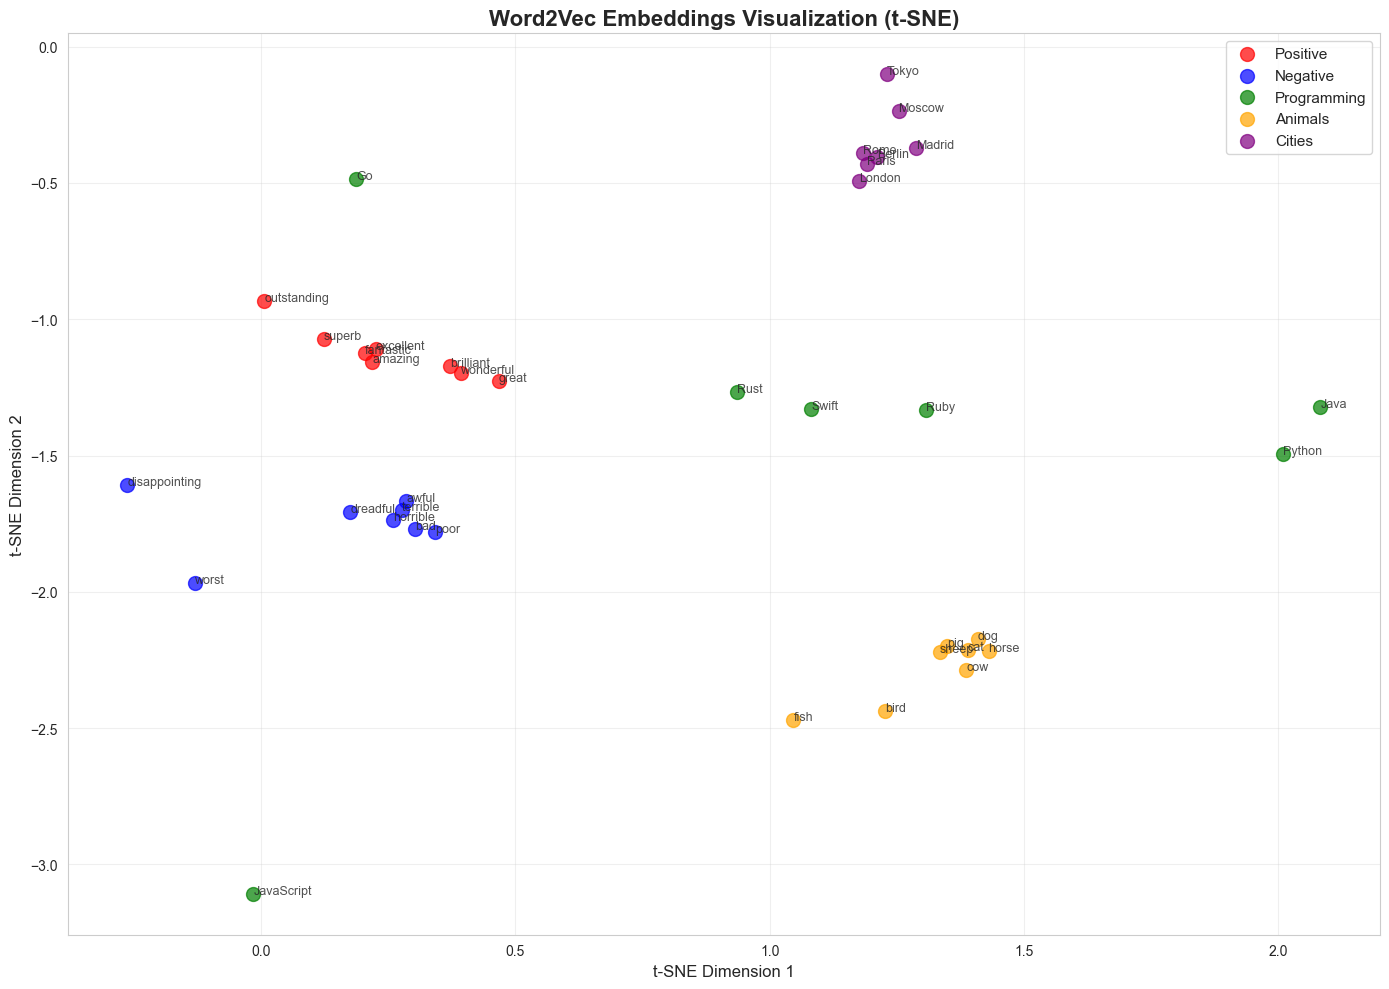


💡 Notice: Words with similar meanings cluster together!
   - Positive words cluster together
   - Negative words cluster together
   - This is semantic understanding - embeddings capture meaning!


In [29]:
# Visualize Word2Vec embeddings with t-SNE
if word2vec_model is not None:
    # Get words from example groups
    all_words = []
    for words in example_words.values():
        all_words.extend(words)
    
    words_in_model = [w for w in all_words if w in word2vec_model]
    
    if len(words_in_model) > 0:
        embeddings = np.array([word2vec_model[w] for w in words_in_model])
        
        print("\n" + "="*70)
        print("Visualizing Word2Vec Embeddings with t-SNE...")
        print("="*70)
        print("(This may take a moment - reducing 300D to 2D for visualization)")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(words_in_model)-1))
        embeddings_2d = tsne.fit_transform(embeddings)
        
        # Plot
        plt.figure(figsize=(14, 10))
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        color_map = {category: colors[i] for i, category in enumerate(example_words.keys())}
        
        for category, words in example_words.items():
            category_words = [w for w in words if w in word2vec_model]
            if category_words:
                indices = [words_in_model.index(w) for w in category_words]
                x_coords = embeddings_2d[indices, 0]
                y_coords = embeddings_2d[indices, 1]
                plt.scatter(x_coords, y_coords, c=color_map[category], 
                           label=category.capitalize(), s=100, alpha=0.7)
                
                for word, x, y in zip(category_words, x_coords, y_coords):
                    plt.annotate(word, (x, y), fontsize=9, alpha=0.8)
        
        plt.title('Word2Vec Embeddings Visualization (t-SNE)', fontsize=16, fontweight='bold')
        plt.xlabel('t-SNE Dimension 1', fontsize=12)
        plt.ylabel('t-SNE Dimension 2', fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\n💡 Notice: Words with similar meanings cluster together!")
        print("   - Positive words cluster together")
        print("   - Negative words cluster together")
        print("   - This is semantic understanding - embeddings capture meaning!")
    else:
        print("⚠️ No words from example groups found in Word2Vec model")
else:
    print("⚠️ Word2Vec model not available - cannot visualize")


In [30]:
# Vector arithmetic example - THE FAMOUS EXAMPLE!
if word2vec_model is not None:
    print("Vector Arithmetic - The Magic of Embeddings!")
    print("=" * 70)
    
    # Try the famous example: king - man + woman ≈ queen
    try:
        result = word2vec_model.most_similar(
            positive=['woman', 'king'],
            negative=['man'],
            topn=5
        )
        print("\nking - man + woman ≈ ?")
        print("Result:")
        for word, similarity in result:
            print(f"  '{word}': {similarity:.4f}")
        
        if result[0][0].lower() == 'queen':
            print("\n✓ Perfect! The relationship is preserved!")
        else:
            print(f"\n⚠️ Expected 'queen' but got '{result[0][0]}'")
            print("   (This can vary - the relationship should still be preserved)")
    except Exception as e:
        print(f"⚠️ Could not compute vector arithmetic: {e}")
    
    print("\n💡 Key Insight: Embeddings capture RELATIONSHIPS, not just similarity!")
    print("   Directions in embedding space represent semantic relationships")
else:
    print("⚠️ Word2Vec model not available - skipping vector arithmetic")


Vector Arithmetic - The Magic of Embeddings!

king - man + woman ≈ ?
Result:
  'queen': 0.7118
  'monarch': 0.6190
  'princess': 0.5902
  'crown_prince': 0.5499
  'prince': 0.5377

✓ Perfect! The relationship is preserved!

💡 Key Insight: Embeddings capture RELATIONSHIPS, not just similarity!
   Directions in embedding space represent semantic relationships


In [31]:
# Summary: Word2Vec Exploration
print("\n" + "="*70)
print("Word2Vec Summary")
print("="*70)
print("\n✅ What we've explored:")
print("   - Word similarities (semantic understanding)")
print("   - Vector arithmetic (king - man + woman ≈ queen)")
print("   - t-SNE visualization (words cluster by meaning - you saw the plot!)")
print("   - OOV handling (limitations)")
print("\n💡 Key Insight: Word2Vec captures semantic meaning!")
print("   Similar words are close in embedding space (you saw this in the t-SNE plot!).")
print("\n   Next: Explore GloVe (global statistics) and FastText (OOV handling)")



Word2Vec Summary

✅ What we've explored:
   - Word similarities (semantic understanding)
   - Vector arithmetic (king - man + woman ≈ queen)
   - t-SNE visualization (words cluster by meaning - you saw the plot!)
   - OOV handling (limitations)

💡 Key Insight: Word2Vec captures semantic meaning!
   Similar words are close in embedding space (you saw this in the t-SNE plot!).

   Next: Explore GloVe (global statistics) and FastText (OOV handling)


---

## Section 4: GloVe - Global Vectors

**GloVe Embeddings - Pre-trained on Wikipedia + Gigaword**

**Key Difference from Word2Vec:**
- Word2Vec: Looks at nearby words (local context window)
- GloVe: Looks at ALL word pairs in entire text (global co-occurrence statistics)

**Analogy**: 
- Word2Vec = local gossip (learns from immediate neighbors)
- GloVe = global reputation (learns from overall patterns)

**Reference**: 
- GloVe paper: Pennington et al., 2014 - "Global Vectors for Word Representation"
- Pre-trained model: Trained on Wikipedia + Gigaword (6 billion tokens)

**What we'll do**: 
- Load GloVe model
- Explore word similarities
- Compare with Word2Vec
- Visualize with t-SNE


In [32]:
# Load GloVe embeddings
print(f"Loading GloVe model ({embedding_dim} dimensions)...")
print("This may take a few minutes on first run...")

try:
    import gensim.downloader as api
    glove_model = api.load(f'glove-wiki-gigaword-{embedding_dim}')
    print(f"✓ GloVe model loaded successfully!")
    print(f"  Vocabulary size: {len(glove_model.key_to_index)} words")
    print(f"  Vector dimensions: {embedding_dim}")
except Exception as e:
    print(f"⚠️ Error loading GloVe: {e}")
    print("Trying alternative loading method...")
    try:
        glove_model = api.load('glove-wiki-gigaword-300')
        print("✓ Loaded GloVe model (300 dimensions)")
    except:
        print("⚠️ Could not load GloVe model.")
        print("  Please ensure gensim is installed and models are available")
        glove_model = None


Loading GloVe model (300 dimensions)...
This may take a few minutes on first run...
✓ GloVe model loaded successfully!
  Vocabulary size: 400000 words
  Vector dimensions: 300


### Exploring GloVe - Word Similarities & Comparison


In [33]:
# Show word similarities - Compare with Word2Vec
if glove_model is not None:
    print("Word Similarities - GloVe vs Word2Vec Comparison:")
    print("=" * 70)
    
    test_word = "great"
    
    if test_word in glove_model:
        similar_glove = glove_model.most_similar(test_word, topn=5)
        print(f"\nGloVe - Words similar to '{test_word}':")
        for word, similarity in similar_glove:
            print(f"  '{word}': {similarity:.4f}")
        
        if word2vec_model is not None and test_word in word2vec_model:
            similar_w2v = word2vec_model.most_similar(test_word, topn=5)
            print(f"\nWord2Vec - Words similar to '{test_word}':")
            for word, similarity in similar_w2v:
                print(f"  '{word}': {similarity:.4f}")
            
            print("\n💡 Notice: Both find similar words, but rankings may differ")
            print("   GloVe uses global statistics, Word2Vec uses local context")
    else:
        print(f"'{test_word}' not in GloVe vocabulary")
else:
    print("⚠️ GloVe model not available - skipping similarity examples")


Word Similarities - GloVe vs Word2Vec Comparison:

GloVe - Words similar to 'great':
  'greatest': 0.6583
  'good': 0.6410
  'tremendous': 0.6300
  'well': 0.5856
  'especially': 0.5592

Word2Vec - Words similar to 'great':
  'terrific': 0.7989
  'fantastic': 0.7935
  'tremendous': 0.7749
  'wonderful': 0.7648
  'good': 0.7292

💡 Notice: Both find similar words, but rankings may differ
   GloVe uses global statistics, Word2Vec uses local context


Applying t-SNE to GloVe embeddings...


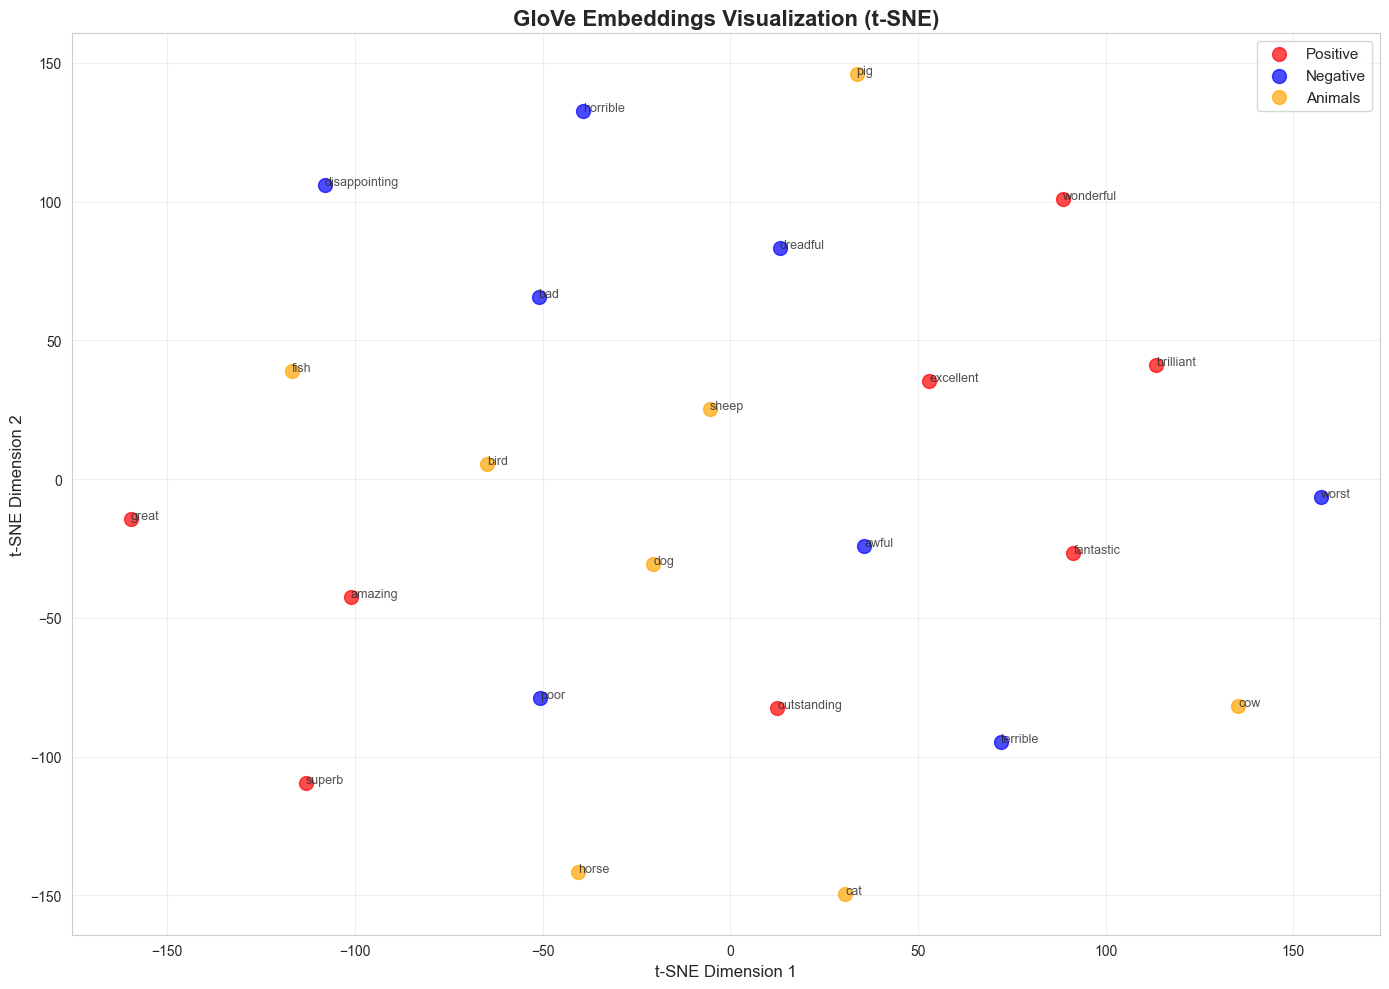


💡 GloVe also clusters words by meaning!
   Global statistics capture similar patterns to local context


In [34]:
# Visualize GloVe embeddings with t-SNE
if glove_model is not None:
    # Get words from example groups
    all_words = []
    for words in example_words.values():
        all_words.extend(words)
    
    words_in_model = [w for w in all_words if w in glove_model]
    
    if len(words_in_model) > 0:
        embeddings = np.array([glove_model[w] for w in words_in_model])
        
        print("Applying t-SNE to GloVe embeddings...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(words_in_model)-1))
        embeddings_2d = tsne.fit_transform(embeddings)
        
        # Plot
        plt.figure(figsize=(14, 10))
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        color_map = {category: colors[i] for i, category in enumerate(example_words.keys())}
        
        for category, words in example_words.items():
            category_words = [w for w in words if w in glove_model]
            if category_words:
                indices = [words_in_model.index(w) for w in category_words]
                x_coords = embeddings_2d[indices, 0]
                y_coords = embeddings_2d[indices, 1]
                plt.scatter(x_coords, y_coords, c=color_map[category], 
                           label=category.capitalize(), s=100, alpha=0.7)
                
                for word, x, y in zip(category_words, x_coords, y_coords):
                    plt.annotate(word, (x, y), fontsize=9, alpha=0.8)
        
        plt.title('GloVe Embeddings Visualization (t-SNE)', fontsize=16, fontweight='bold')
        plt.xlabel('t-SNE Dimension 1', fontsize=12)
        plt.ylabel('t-SNE Dimension 2', fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\n💡 GloVe also clusters words by meaning!")
        print("   Global statistics capture similar patterns to local context")
else:
    print("⚠️ GloVe model not available - cannot visualize")


---

## Section 5: FastText - Handling the Unknown

**FastText Embeddings - Uses Subword Information**

**Key Advantage**: Handles OOV (Out-of-Vocabulary) words better than Word2Vec or GloVe!

**How it works**: Breaks words into subwords (character n-grams), so even unknown words get embeddings.

**Analogy**: Like recognizing a word even if it's misspelled - you recognize parts!

**Reference**: 
- FastText paper: Bojanowski et al., 2017 - "Enriching Word Vectors with Subword Information"
- Pre-trained model: Trained on Wikipedia + News

**What we'll do**: 
- Load FastText model
- Explore OOV handling (its key advantage!)
- See how subwords enable embeddings for unknown words


In [35]:
# Load FastText embeddings
print(f"Loading FastText model ({embedding_dim} dimensions)...")
print("This may take a few minutes on first run...")

try:
    import gensim.downloader as api
    fasttext_model = api.load(f'fasttext-wiki-news-subwords-{embedding_dim}')
    print(f"✓ FastText model loaded successfully!")
    print(f"  Vocabulary size: {len(fasttext_model.key_to_index)} words")
    print(f"  Vector dimensions: {embedding_dim}")
except Exception as e:
    print(f"⚠️ Error loading FastText: {e}")
    print("Trying alternative loading method...")
    try:
        fasttext_model = api.load('fasttext-wiki-news-subwords-300')
        print("✓ Loaded FastText model (300 dimensions)")
    except:
        print("⚠️ Could not load FastText model.")
        print("  Please ensure gensim is installed and models are available")
        fasttext_model = None


Loading FastText model (300 dimensions)...
This may take a few minutes on first run...
✓ FastText model loaded successfully!
  Vocabulary size: 999999 words
  Vector dimensions: 300


In [36]:
# Load FastText embeddings
print(f"Loading FastText model ({embedding_dim} dimensions)...")
print("This may take a few minutes on first run...")

try:
    import gensim.downloader as api
    fasttext_model = api.load(f'fasttext-wiki-news-subwords-{embedding_dim}')
    print(f"✓ FastText model loaded successfully!")
    print(f"  Vocabulary size: {len(fasttext_model.key_to_index)} words")
except Exception as e:
    print(f"⚠️ Error loading FastText: {e}")
    print("Trying alternative loading method...")
    try:
        fasttext_model = api.load('fasttext-wiki-news-subwords-300')
        print("✓ Loaded FastText model (300 dimensions)")
    except:
        print("⚠️ Could not load FastText model.")
        print("  Please ensure gensim is installed and models are available")
        fasttext_model = None


Loading FastText model (300 dimensions)...
This may take a few minutes on first run...
✓ FastText model loaded successfully!
  Vocabulary size: 999999 words



Visualizing FastText Embeddings with t-SNE...
(This may take a moment - reducing 300D to 2D for visualization)


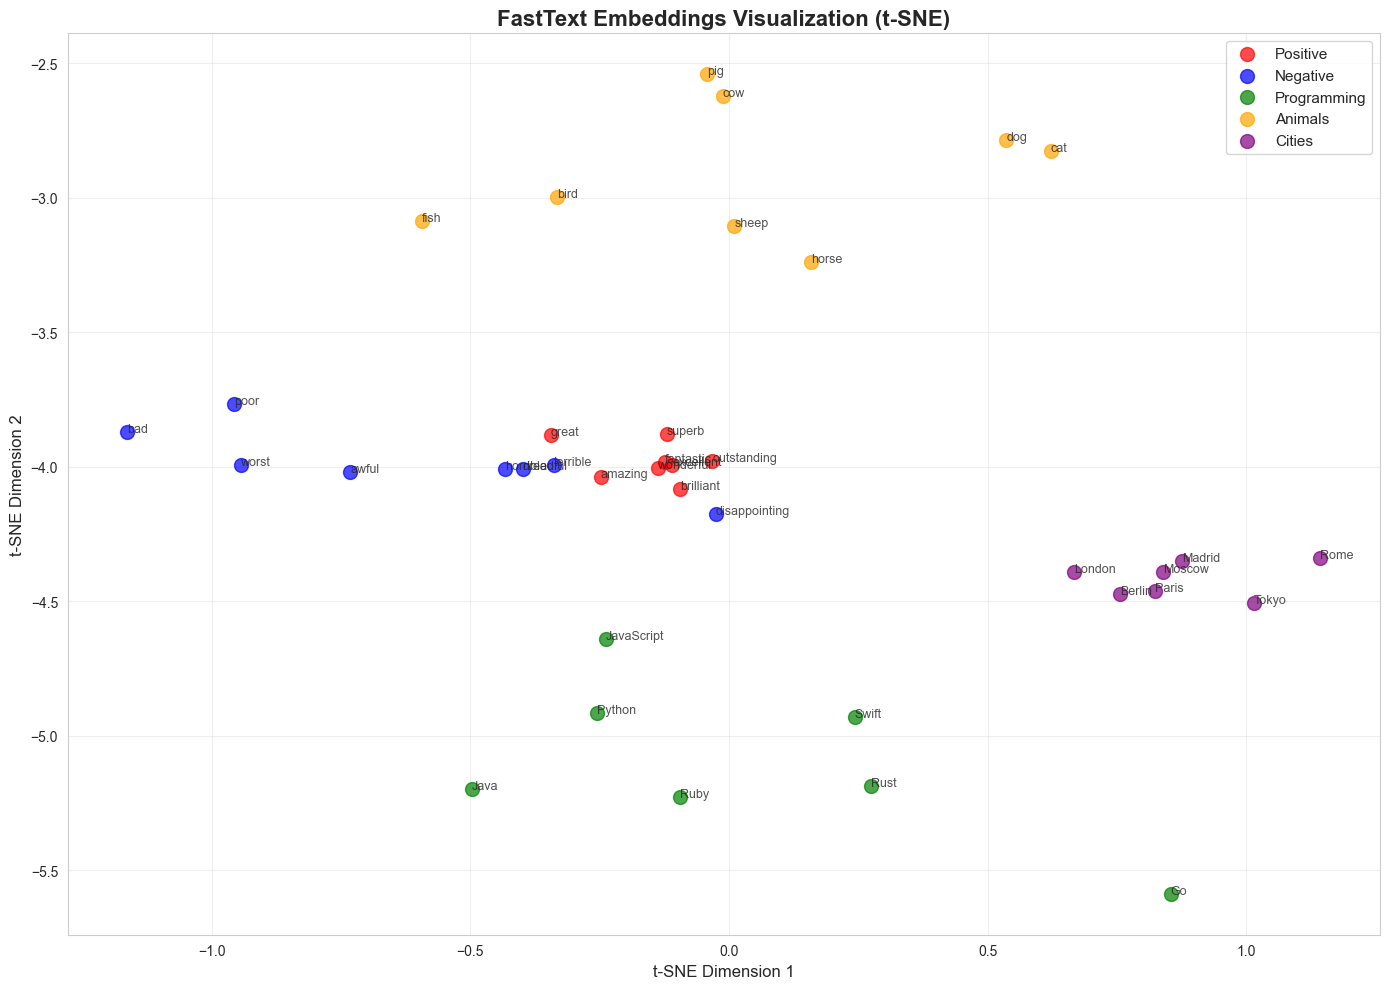


💡 Notice: FastText also clusters words by meaning!
   - Similar to Word2Vec and GloVe for known words
   - But FastText can handle OOV words (its advantage!)


In [37]:
# Visualize FastText embeddings with t-SNE
if fasttext_model is not None:
    # Get words from example groups
    all_words = []
    for words in example_words.values():
        all_words.extend(words)
    
    words_in_model = [w for w in all_words if w in fasttext_model]
    
    if len(words_in_model) > 0:
        embeddings = np.array([fasttext_model[w] for w in words_in_model])
        
        print("\n" + "="*70)
        print("Visualizing FastText Embeddings with t-SNE...")
        print("="*70)
        print("(This may take a moment - reducing 300D to 2D for visualization)")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(words_in_model)-1))
        embeddings_2d = tsne.fit_transform(embeddings)
        
        # Plot
        plt.figure(figsize=(14, 10))
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        color_map = {category: colors[i] for i, category in enumerate(example_words.keys())}
        
        for category, words in example_words.items():
            category_words = [w for w in words if w in fasttext_model]
            if category_words:
                indices = [words_in_model.index(w) for w in category_words]
                x_coords = embeddings_2d[indices, 0]
                y_coords = embeddings_2d[indices, 1]
                plt.scatter(x_coords, y_coords, c=color_map[category], 
                           label=category.capitalize(), s=100, alpha=0.7)
                
                for word, x, y in zip(category_words, x_coords, y_coords):
                    plt.annotate(word, (x, y), fontsize=9, alpha=0.8)
        
        plt.title('FastText Embeddings Visualization (t-SNE)', fontsize=16, fontweight='bold')
        plt.xlabel('t-SNE Dimension 1', fontsize=12)
        plt.ylabel('t-SNE Dimension 2', fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\n💡 Notice: FastText also clusters words by meaning!")
        print("   - Similar to Word2Vec and GloVe for known words")
        print("   - But FastText can handle OOV words (its advantage!)")
    else:
        print("⚠️ No words from example groups found in FastText model")
else:
    print("⚠️ FastText model not available - cannot visualize")


In [38]:
# Show OOV word example - THE KEY ADVANTAGE OF FASTTEXT!
if fasttext_model is not None:
    print("OOV Word Handling - FastText's Key Advantage:")
    print("=" * 70)
    
    # Test with a word that might be OOV
    test_oov_words = ["misunderstood", "unhappiness", "teh", "amazzing"]
    
    for word in test_oov_words:
        print(f"\nTesting word: '{word}'")
        
        # Check Word2Vec/GloVe (if available)
        if word2vec_model is not None:
            w2v_available = word in word2vec_model
            print(f"  Word2Vec: {'✓ Available' if w2v_available else '✗ OOV (not available)'}")
        
        if glove_model is not None:
            glove_available = word in glove_model
            print(f"  GloVe:    {'✓ Available' if glove_available else '✗ OOV (not available)'}")
        
        # FastText can handle OOV!
        try:
            # FastText can get embedding even for OOV words
            fasttext_vec = fasttext_model[word]
            similar_fasttext = fasttext_model.most_similar(word, topn=3)
            print(f"  FastText: ✓ Works! (uses subwords)")
            print(f"    Similar words: {[w for w, _ in similar_fasttext]}")
        except:
            print(f"  FastText: ✗ Not available")
    
    print("\n💡 Key Insight: FastText handles OOV words better!")
    print("   It breaks words into subwords, so even unknown words get embeddings")
else:
    print("⚠️ FastText model not available - skipping OOV examples")


OOV Word Handling - FastText's Key Advantage:

Testing word: 'misunderstood'
  Word2Vec: ✓ Available
  GloVe:    ✓ Available
  FastText: ✓ Works! (uses subwords)
    Similar words: ['misinterpreted', 'mis-understood', 'misconstrued']

Testing word: 'unhappiness'
  Word2Vec: ✓ Available
  GloVe:    ✓ Available
  FastText: ✓ Works! (uses subwords)
    Similar words: ['dissatisfaction', 'misery', 'discontent']

Testing word: 'teh'
  Word2Vec: ✓ Available
  GloVe:    ✓ Available
  FastText: ✓ Works! (uses subwords)
    Similar words: ['hte', 'tthe', 'thte']

Testing word: 'amazzing'
  Word2Vec: ✗ OOV (not available)
  GloVe:    ✗ OOV (not available)
  FastText: ✗ Not available

💡 Key Insight: FastText handles OOV words better!
   It breaks words into subwords, so even unknown words get embeddings


In [39]:
# Summary: FastText Exploration
print("\n" + "="*70)
print("FastText Summary")
print("="*70)
print("\n✅ What we've explored:")
print("   - OOV handling (its key advantage!)")
print("   - How subwords enable embeddings for unknown words")
print("   - t-SNE visualization (words cluster by meaning - similar to Word2Vec/GloVe!)")
print("\n💡 Key Insight: FastText handles OOV words better!")
print("   It breaks words into subwords, so even unknown words get embeddings.")
print("   For known words, it clusters similarly to Word2Vec/GloVe (you saw this in the plot!).")
print("\n   Next: Explore how preprocessing affects embeddings!")



FastText Summary

✅ What we've explored:
   - OOV handling (its key advantage!)
   - How subwords enable embeddings for unknown words
   - t-SNE visualization (words cluster by meaning - similar to Word2Vec/GloVe!)

💡 Key Insight: FastText handles OOV words better!
   It breaks words into subwords, so even unknown words get embeddings.
   For known words, it clusters similarly to Word2Vec/GloVe (you saw this in the plot!).

   Next: Explore how preprocessing affects embeddings!


---

## Section 6: Preprocessing Impact on Embeddings

**How Does Preprocessing Affect Embeddings?**

**Key Question**: Does preprocessing help or hurt embeddings? (Different from TF-IDF!)

**Remember from Class 1 & 2**: 
- You learned preprocessing: lowercase, stopword removal, lemmatization, etc.
- With TF-IDF, more preprocessing usually helps (reduces noise, normalizes text)
- **With embeddings, the story is different** - context matters!

**Why This Matters**: 
- Embeddings learn from word context and relationships
- Over-cleaning can remove important context
- Example: "not good" needs both words - removing "not" loses the negation!
- But some preprocessing still helps (lowercase, basic cleaning)

**What we'll explore**:
- How preprocessing affects word similarities
- How preprocessing affects semantic search results
- When less preprocessing is better (context matters!)


In [40]:
# Preprocessing functions (you know these from Class 1 & 2!)
def preprocess_baseline(text):
    """No preprocessing - raw text"""
    return text

def preprocess_lowercase(text):
    """Only lowercase"""
    return text.lower()

def preprocess_simple(text):
    """Lowercase + basic cleaning"""
    import re
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text.strip()

# Test how preprocessing affects word similarities
if word2vec_model is not None:
    print("Preprocessing Impact on Word Similarities:")
    print("=" * 70)
    
    test_word = "great"
    
    # Test with different preprocessing
    print(f"\nTesting word: '{test_word}'")
    print("\n1. No preprocessing (raw):")
    if test_word in word2vec_model:
        similar = word2vec_model.most_similar(test_word, topn=5)
        for word, sim in similar:
            print(f"   {word}: {sim:.4f}")
    
    print("\n2. Lowercase:")
    test_word_lower = test_word.lower()
    if test_word_lower in word2vec_model:
        similar = word2vec_model.most_similar(test_word_lower, topn=5)
        for word, sim in similar:
            print(f"   {word}: {sim:.4f}")
    
    print("\n💡 Notice: Preprocessing affects which words are found!")
    print("   - 'Great' vs 'great' might have different embeddings")
    print("   - Lowercase helps normalize, but sometimes preserves case-specific meanings")
else:
    print("⚠️ Word2Vec model not available")


Preprocessing Impact on Word Similarities:

Testing word: 'great'

1. No preprocessing (raw):
   terrific: 0.7989
   fantastic: 0.7935
   tremendous: 0.7749
   wonderful: 0.7648
   good: 0.7292

2. Lowercase:
   terrific: 0.7989
   fantastic: 0.7935
   tremendous: 0.7749
   wonderful: 0.7648
   good: 0.7292

💡 Notice: Preprocessing affects which words are found!
   - 'Great' vs 'great' might have different embeddings
   - Lowercase helps normalize, but sometimes preserves case-specific meanings


---

## Section 7: Try It Yourself - Semantic Search!

**Now let's test all embedding methods with real search!**

You learned similarity search with TF-IDF in Class 2. Now let's see how embeddings enable **semantic search** - understanding meaning, not just keywords!

**What we'll do:**
- Load a sample of IMDB reviews
- Create embeddings using all methods (Word2Vec, GloVe, FastText)
- Run a search query
- Compare results - see how semantic search finds relevant reviews even without exact keyword matches!


In [41]:
# Load IMDB dataset sample for search (if not already loaded)
import os
import pandas as pd

if 'reviews' not in locals() or reviews is None:
    # Try to load dataset
    if os.path.exists('data/IMDB Dataset.csv'):
        df = pd.read_csv('data/IMDB Dataset.csv')
    elif os.path.exists('../data/IMDB Dataset.csv'):
        df = pd.read_csv('../data/IMDB Dataset.csv')
    else:
        print("⚠️ IMDB Dataset.csv not found. Please download from:")
        print("   https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
        df = None
    
    if df is not None:
        # Use a sample for faster processing
        sample_size = 1000
        df_sample = df.sample(n=min(sample_size, len(df)), random_state=42).reset_index(drop=True)
        reviews = df_sample['review'].values.tolist()
        print(f"✓ Loaded {len(reviews)} reviews for search")
    else:
        reviews = None
        print("⚠️ Cannot proceed without dataset")
else:
    print(f"✓ Using {len(reviews)} reviews already loaded")


✓ Using 1000 reviews already loaded


In [42]:
# Create embeddings for all reviews using different methods (if not already created)
if reviews is not None and ('embeddings_dict' not in locals() or len(embeddings_dict) == 0):
    print("\nCreating document embeddings...")
    print("=" * 70)
    
    embeddings_dict = {}
    
    # Helper function
    def average_word_vectors(text, model, dim=300):
        words = simple_preprocess(text).split()
        vectors = []
        for word in words:
            if word in model:
                vectors.append(model[word])
        if len(vectors) == 0:
            return np.zeros(dim)
        return np.mean(vectors, axis=0)
    
    # Word2Vec embeddings
    if word2vec_model is not None:
        print("\n1. Creating Word2Vec embeddings...")
        w2v_embeddings = np.array([average_word_vectors(review, word2vec_model, embedding_dim) 
                                   for review in reviews])
        embeddings_dict['Word2Vec'] = w2v_embeddings
        print(f"   ✓ Word2Vec embeddings: {w2v_embeddings.shape}")
    
    # GloVe embeddings
    if glove_model is not None:
        print("\n2. Creating GloVe embeddings...")
        glove_embeddings = np.array([average_word_vectors(review, glove_model, embedding_dim) 
                                    for review in reviews])
        embeddings_dict['GloVe'] = glove_embeddings
        print(f"   ✓ GloVe embeddings: {glove_embeddings.shape}")
    
    # FastText embeddings
    if fasttext_model is not None:
        print("\n3. Creating FastText embeddings...")
        def average_fasttext(text, model, dim=300):
            words = simple_preprocess(text).split()
            vectors = []
            for word in words:
                try:
                    vectors.append(model[word])  # FastText handles OOV!
                except:
                    pass
            if len(vectors) == 0:
                return np.zeros(dim)
            return np.mean(vectors, axis=0)
        
        fasttext_embeddings = np.array([average_fasttext(review, fasttext_model, embedding_dim) 
                                       for review in reviews])
        embeddings_dict['FastText'] = fasttext_embeddings
        print(f"   ✓ FastText embeddings: {fasttext_embeddings.shape}")
    
    print("\n" + "=" * 70)
    print("✓ All embeddings created! Ready for search!")
elif reviews is None:
    embeddings_dict = {}
    print("⚠️ Cannot create embeddings without dataset")
else:
    print("✓ Embeddings already created!")



Creating document embeddings...

1. Creating Word2Vec embeddings...
   ✓ Word2Vec embeddings: (1000, 300)

2. Creating GloVe embeddings...
   ✓ GloVe embeddings: (1000, 300)

3. Creating FastText embeddings...
   ✓ FastText embeddings: (1000, 300)

✓ All embeddings created! Ready for search!


SEMANTIC SEARCH - Testing All Embedding Methods

Query: 'amazing action movie with great special effects'

Searching for reviews similar to your query...


Word2Vec Results (Top 3):

1. Similarity: 0.7403
   Review: Well when watching this film late one night I was simple amazed by it's greatness. Fantastic script, great acting, costumes and special effects, and t...

2. Similarity: 0.7262
   Review: The film is hugely enjoyable with a great cast, and excellent direction by James Eves. The movie is entertaining with a very charismatic performance f...

3. Similarity: 0.7253
   Review: This movie is very similar to Death Warrant with Jean-Claude Van Damme and also has some similarities to Island of Fire with Jackie Chan and I also he...

GloVe Results (Top 3):

1. Similarity: 0.8545
   Review: This movie is very similar to Death Warrant with Jean-Claude Van Damme and also has some similarities to Island of Fire with Jackie Chan and I also he...

2. Similarity: 0.8506
   Review: This fil

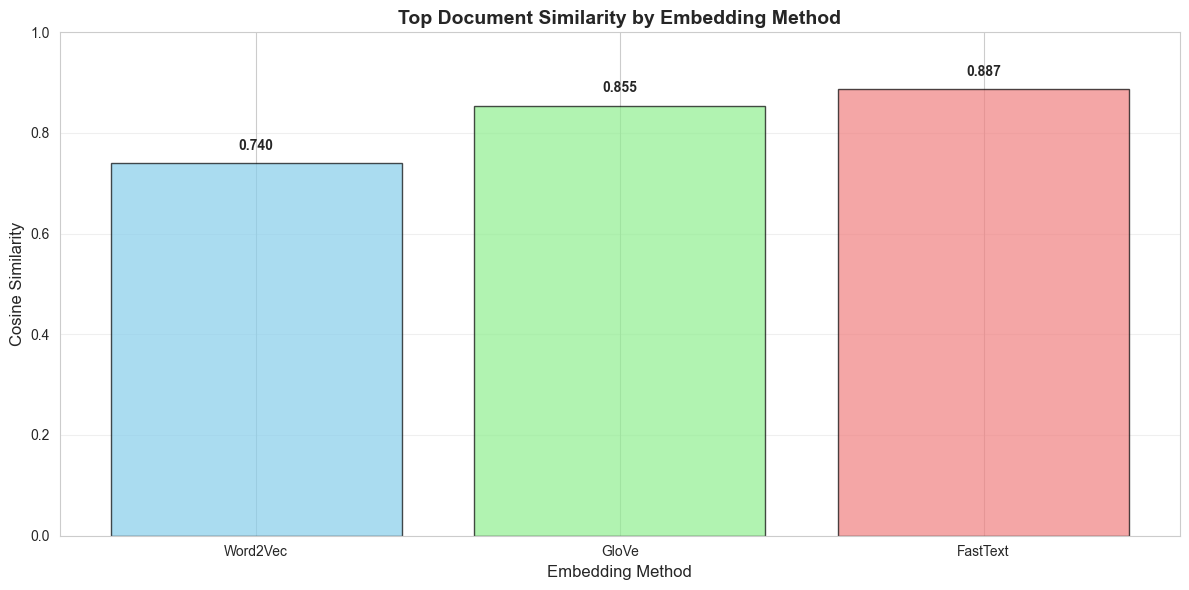


💡 Notice: All methods find similar documents!
   - Similarity scores show how close documents are to your query
   - Higher scores = more relevant (semantic match)

💡 Key Observations:
   - Semantic search finds relevant reviews even without exact keywords!
   - 'amazing' finds reviews with 'fantastic', 'incredible', 'wonderful'
   - 'action movie' finds reviews about action films even if they don't say 'action'
   - This is the power of embeddings - understanding meaning!


In [43]:
# EDIT THIS: Try your own search query!
query = "amazing action movie with great special effects"

print("=" * 70)
print("SEMANTIC SEARCH - Testing All Embedding Methods")
print("=" * 70)
print(f"\nQuery: '{query}'")
print("\nSearching for reviews similar to your query...\n")

if reviews is not None and len(embeddings_dict) > 0:
    from sklearn.metrics.pairwise import cosine_similarity
    
    # Helper function
    def average_word_vectors(text, model, dim=300):
        words = simple_preprocess(text).split()
        vectors = []
        for word in words:
            if word in model:
                vectors.append(model[word])
        if len(vectors) == 0:
            return np.zeros(dim)
        return np.mean(vectors, axis=0)
    
    # Create query embeddings for each method
    query_embeddings = {}
    
    if 'Word2Vec' in embeddings_dict and word2vec_model is not None:
        query_embeddings['Word2Vec'] = average_word_vectors(query, word2vec_model, embedding_dim)
    
    if 'GloVe' in embeddings_dict and glove_model is not None:
        query_embeddings['GloVe'] = average_word_vectors(query, glove_model, embedding_dim)
    
    if 'FastText' in embeddings_dict and fasttext_model is not None:
        def average_fasttext(text, model, dim=300):
            words = simple_preprocess(text).split()
            vectors = []
            for word in words:
                try:
                    vectors.append(model[word])
                except:
                    pass
            if len(vectors) == 0:
                return np.zeros(dim)
            return np.mean(vectors, axis=0)
        query_embeddings['FastText'] = average_fasttext(query, fasttext_model, embedding_dim)
    
    # Search and display top results for each method
    top_k = 3
    
    for method_name, query_emb in query_embeddings.items():
        if method_name in embeddings_dict:
            print(f"\n{'='*70}")
            print(f"{method_name} Results (Top {top_k}):")
            print("="*70)
            
            # Calculate similarities
            similarities = cosine_similarity([query_emb], embeddings_dict[method_name])[0]
            
            # Get top k indices
            top_indices = np.argsort(similarities)[::-1][:top_k]
            
            for i, idx in enumerate(top_indices, 1):
                similarity = similarities[idx]
                review = reviews[idx]
                print(f"\n{i}. Similarity: {similarity:.4f}")
                print(f"   Review: {review[:150]}...")
    
    # Visualize document similarities (quick visualization)
    if len(query_embeddings) > 0 and len(embeddings_dict) > 0:
        print("\n" + "="*70)
        print("Document Similarity Visualization")
        print("="*70)
        
        # Create a simple bar chart comparing top results across methods
        fig, ax = plt.subplots(figsize=(12, 6))
        
        methods = []
        top_similarities = []
        
        for method_name, query_emb in query_embeddings.items():
            if method_name in embeddings_dict:
                similarities = cosine_similarity([query_emb], embeddings_dict[method_name])[0]
                top_sim = np.max(similarities)  # Best match
                methods.append(method_name)
                top_similarities.append(top_sim)
        
        if methods:
            bars = ax.bar(methods, top_similarities, color=['skyblue', 'lightgreen', 'lightcoral'], 
                         alpha=0.7, edgecolor='black')
            ax.set_title('Top Document Similarity by Embedding Method', fontsize=14, fontweight='bold')
            ax.set_ylabel('Cosine Similarity', fontsize=12)
            ax.set_xlabel('Embedding Method', fontsize=12)
            ax.set_ylim([0, 1])
            ax.grid(axis='y', alpha=0.3)
            
            for bar, sim in zip(bars, top_similarities):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                        f'{sim:.3f}', ha='center', va='bottom', fontweight='bold')
            
            plt.tight_layout()
            plt.show()
            
            print("\n💡 Notice: All methods find similar documents!")
            print("   - Similarity scores show how close documents are to your query")
            print("   - Higher scores = more relevant (semantic match)")
    
    print("\n" + "="*70)
    print("💡 Key Observations:")
    print("   - Semantic search finds relevant reviews even without exact keywords!")
    print("   - 'amazing' finds reviews with 'fantastic', 'incredible', 'wonderful'")
    print("   - 'action movie' finds reviews about action films even if they don't say 'action'")
    print("   - This is the power of embeddings - understanding meaning!")
    
else:
    print("⚠️ Cannot perform search - embeddings or dataset not available")


---

## Section 8: Comparison & Summary

**Let's compare all embedding methods we've explored!**


In [44]:
# Feature comparison table
print("Embedding Methods Comparison:")
print("=" * 70)

features_comparison = {
    'Method': ['Word2Vec', 'GloVe', 'FastText'],
    'Type': ['Word embeddings', 'Word embeddings', 'Word embeddings'],
    'OOV Handling': ['Poor', 'Poor', 'Good'],
    'Training': ['Local context', 'Global co-occurrence', 'Subwords'],
    'Best For': ['General purpose', 'Large corpus', 'OOV words'],
    'Level': ['Word', 'Word', 'Word']
}

features_df = pd.DataFrame(features_comparison)
print("\n" + features_df.to_string(index=False))

print("\n💡 Decision Framework:")
print("  • General word embeddings? → Word2Vec or GloVe")
print("  • Dealing with OOV words? → FastText")
print("  • Large corpus? → GloVe")
print("  • Need semantic understanding? → Any of these (vs TF-IDF)")
print("\n  Note: Sentence embeddings (Sentence-BERT) are in Part 2!")


Embedding Methods Comparison:

  Method            Type OOV Handling             Training        Best For Level
Word2Vec Word embeddings         Poor        Local context General purpose  Word
   GloVe Word embeddings         Poor Global co-occurrence    Large corpus  Word
FastText Word embeddings         Good             Subwords       OOV words  Word

💡 Decision Framework:
  • General word embeddings? → Word2Vec or GloVe
  • Dealing with OOV words? → FastText
  • Large corpus? → GloVe
  • Need semantic understanding? → Any of these (vs TF-IDF)

  Note: Sentence embeddings (Sentence-BERT) are in Part 2!


---

## Summary

**What You Learned:**

1. ✅ **Word Embeddings**: Dense vectors that capture semantic meaning (vs sparse TF-IDF)
2. ✅ **Word2Vec**: Semantic embeddings from local context - explored similarities, vector arithmetic, OOV handling
3. ✅ **GloVe**: Semantic embeddings from global co-occurrence - explored similarities, compared with Word2Vec
4. ✅ **FastText**: Semantic embeddings with subwords - explored OOV handling (its key advantage!)
5. ✅ **Preprocessing Impact**: How preprocessing affects embeddings (sometimes less is more!)
6. ✅ **Semantic Search**: Tested all methods with real search queries!

**Key Insights:**

- **Embeddings solve the limitation** you learned about in Class 2
- **"great" and "excellent" are similar** in embedding space (semantics!)
- **TF-IDF treats them as different** (syntax only)
- **Semantic search** finds relevant content even without exact keywords!
- **Preprocessing affects embeddings differently** than TF-IDF - context matters!
- **Each embedding method has strengths**: 
  - Word2Vec (local context)
  - GloVe (global statistics)
  - FastText (OOV handling)

**What We Did**:
- Introduced word embeddings (dense vectors vs sparse TF-IDF)
- Explored Word2Vec, GloVe, and FastText
- **Visualized word embeddings** with t-SNE (Word2Vec, GloVe, FastText - saw how similar words cluster!)
- Saw vector arithmetic (king - man + woman ≈ queen)
- Explored preprocessing impact on embeddings
- **Tested semantic search** with all embedding methods (with document similarity visualization!)

**Next**: In Learning Notebook Part 2, we'll:
- Use embeddings for **sentiment analysis (supervised learning)**
- Explore **Sentence-BERT** (modern sentence embeddings)
- Use POS tagging and NER for classification
- Compare sentence embeddings vs word averaging

**Remember**: **Semantic = meaning**. Embeddings understand meaning, not just word patterns! We've introduced and visualized word embeddings. In Part 2, we'll use them for classification and explore sentence embeddings!
